**BIG DATA: Pré-processamento de Dados**

Download Dados Bolsa Família (recomendação: faça a transferência pelo menos dos últimos 6 meses)

Fonte: https://portaldatransparencia.gov.br/download-de-dados/novo-bolsa-familia

Após essa etapa, concatene em um dataframe 2 meses aleatórios dessa fonte (mês a mês).

Vamos comparar o tempo de processamento das bibliotecas Pandas e Polars:

PANDAS

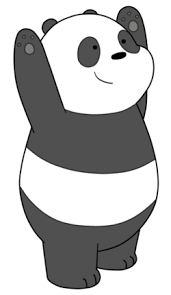

In [1]:
#IMPORTANTE: utilize os dados de 2 meses para evitar a sobrecarga do programa!

import pandas as pd

arquivo1=pd.read_csv("../202501_NovoBolsaFamilia.csv", sep=";", encoding="latin-1") #caminhos dos arquivos
arquivo2=pd.read_csv("../202502_NovoBolsaFamilia.csv", sep=";", encoding="latin-1")

df_pandas=pd.concat([arquivo1,arquivo2])

display(df_pandas.head())

,MÊS COMPETÊNCIA,MÊS REFERÊNCIA,UF,CÓDIGO MUNICÍPIO SIAFI,NOME MUNICÍPIO,CPF FAVORECIDO,NIS FAVORECIDO,NOME FAVORECIDO,VALOR PARCELA
0,202501,202308,SP,7071,SANTOS,***.085.106-**,2.064389e+10,FERNANDA RAMOS TEIXEIRA,"650,00"
1,202501,202309,SP,7071,SANTOS,***.085.106-**,2.064389e+10,FERNANDA RAMOS TEIXEIRA,"650,00"
2,202501,202310,SP,7071,SANTOS,***.085.106-**,2.064389e+10,FERNANDA RAMOS TEIXEIRA,"650,00"
3,202501,202311,SP,7071,SANTOS,***.085.106-**,2.064389e+10,FERNANDA RAMOS TEIXEIRA,"650,00"
4,202501,202312,SP,7071,SANTOS,***.085.106-**,2.064389e+10,FERNANDA RAMOS TEIXEIRA,"650,00"


POLARS

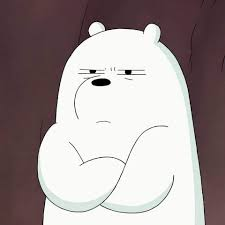

In [2]:
import polars as pl

arquivo1=pl.read_csv("../202501_NovoBolsaFamilia.csv", separator=";", encoding="latin-1") #caminhos dos arquivos
arquivo2=pl.read_csv("../202502_NovoBolsaFamilia.csv", separator=";", encoding="latin-1")

df_polars=pl.concat([arquivo1,arquivo2])

display(df_polars.head())

MÊS COMPETÊNCIA,MÊS REFERÊNCIA,UF,CÓDIGO MUNICÍPIO SIAFI,NOME MUNICÍPIO,CPF FAVORECIDO,NIS FAVORECIDO,NOME FAVORECIDO,VALOR PARCELA
i64,i64,str,i64,str,str,i64,str,str
202501,202308,"""SP""",7071,"""SANTOS""","""***.085.106-**""",20643890445,"""FERNANDA RAMOS TEIXEIRA""","""650,00"""
202501,202309,"""SP""",7071,"""SANTOS""","""***.085.106-**""",20643890445,"""FERNANDA RAMOS TEIXEIRA""","""650,00"""
202501,202310,"""SP""",7071,"""SANTOS""","""***.085.106-**""",20643890445,"""FERNANDA RAMOS TEIXEIRA""","""650,00"""
202501,202311,"""SP""",7071,"""SANTOS""","""***.085.106-**""",20643890445,"""FERNANDA RAMOS TEIXEIRA""","""650,00"""
202501,202312,"""SP""",7071,"""SANTOS""","""***.085.106-**""",20643890445,"""FERNANDA RAMOS TEIXEIRA""","""650,00"""


PARQUET: formato para otimizar o processamentos doa dados.

In [3]:
import pandas as pd
import polars as pl
import pyarrow as pa
import pyarrow.parquet as pq
import os

In [4]:
#Exportação para .parquet com Pandas:

# --- 1. Configuração ---
arquivo_csv = '../202501_NovoBolsaFamilia.csv' # CONFIRME SEU CAMINHO
arquivo_parquet = '202501_NovoBolsaFamilia_PANDAS.parquet'
chunksize = 1_000_000 # 1 milhão de linhas por vez

# --- 2. Verificação do Arquivo de Entrada ---
if not os.path.exists(arquivo_csv):
    print(f"ERRO: Arquivo de entrada não encontrado em: {arquivo_csv}")
else:
    print("Arquivo CSV encontrado. Iniciando conversão em chunks...")

    # --- 3. Criar o Leitor (Iterator) ---
    # É aqui que aplicamos as regras de encoding e separador
    csv_reader = pd.read_csv(
        arquivo_csv,
        chunksize=chunksize,
        sep=';',
        encoding='utf-8',
        encoding_errors='replace' # O equivalente ao 'utf8-lossy'
    )
    
    writer = None  # Inicializa o escritor de Parquet
    schema = None  # Inicializa o schema
    count = 0

    try:
        # --- 4. Loop de Leitura e Escrita ---
        for chunk in csv_reader:
            count += 1
            print(f"Processando chunk {count}...")

            # Converter o DataFrame do Pandas para uma Tabela do PyArrow
            table = pa.Table.from_pandas(chunk)

            if writer is None:
                # Na primeira volta, pegamos o schema e abrimos o escritor
                schema = table.schema
                writer = pq.ParquetWriter(arquivo_parquet, schema=schema)
            
            # Escreve o chunk (tabela) no arquivo Parquet
            writer.write_table(table)

        if writer is not None:
            writer.close()
            print(f"\nSucesso! Arquivo '{arquivo_parquet}' foi criado.")
        else:
            print("Arquivo CSV estava vazio. Nenhum arquivo Parquet foi criado.")

    except Exception as e:
        print(f"Ocorreu um erro no processamento: {e}")
        if writer is not None:
            writer.close() # Tenta fechar o arquivo em caso de erro

Arquivo CSV encontrado. Iniciando conversão em chunks...
Processando chunk 1...
Processando chunk 2...
Processando chunk 3...
Processando chunk 4...
Processando chunk 5...
Processando chunk 6...
Processando chunk 7...
Processando chunk 8...
Processando chunk 9...
Processando chunk 10...
Processando chunk 11...
Processando chunk 12...
Processando chunk 13...
Processando chunk 14...
Processando chunk 15...
Processando chunk 16...
Processando chunk 17...
Processando chunk 18...
Processando chunk 19...
Processando chunk 20...
Processando chunk 21...

Sucesso! Arquivo '202501_NovoBolsaFamilia_PANDAS.parquet' foi criado.


In [5]:
#Exportação para .parquet com Polars:

arquivo_csv2 = '../202501_NovoBolsaFamilia.csv'
arquivo_parquet2 = '202501_NovoBolsaFamilia_POLARS.parquet'

# 1. scan_csv() apenas cria o plano (LazyFrame)
lazy_query = pl.scan_csv(arquivo_csv2, separator=';', encoding='utf8-lossy')

# 2. sink_parquet() executa o plano em modo streaming
#    e salva o resultado direto no disco.
lazy_query.sink_parquet(arquivo_parquet2)

print(f"Arquivo '{arquivo_csv2}' convertido para '{arquivo_parquet2}' com sucesso!")

Arquivo '../202501_NovoBolsaFamilia.csv' convertido para '202501_NovoBolsaFamilia_POLARS.parquet' com sucesso!
